# Airbnb Analysis in New York City

## Introduction 
New York City is a huge city home to millions of people on a daily, but it is also a huge travel hub for many millions of people every year. People frequently travel here to participate in the countless events that this city has to offer. Room lending services such as Airbnb are popular here, which will lead us into an exploration into the open data set of airbnb! Today we will be analyzing the Airbnb open data set in New york city to solve many different questions! 

This data set consists of analyzable information like:
1. the type of room, 
2. the neighborhood, 
3. the neighborhood group, 
4. rating,
5. number of ratings left on a location, 
6. cancellation policy,
7. price,
8. service fee,
9. minimum nights.

We can answer the following questions:
1. What is the average price of an airbnb in different neighborhood groups
2. Is there a relation between room type and price?
3. Which room_type recieves most reviews?
4. Which neighborhood has the most Airbnb ratings?
5. Which neighborhood has the most airbnb listings?
6. Which room_type is most popular in Brooklyn?
7. Is there a correlation between the number of reviews and the price?

## Why I chose these questions?
My goal is to help people who want to do business with airbnb or any other property rental app gain incite on what location would be the best for their property, what type of property would get them the most money, is there a popular type of room in new york city?

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib

#Load dataset
df = pd.read_csv('Airbnb_Open_Data.csv')

#Removing neighborhood groups that aren't real neighborhood groups
valid_boroughs = ["Brooklyn", "Bronx", "Manhattan", "Queens", "Staten Island"]
df = df[df["neighbourhood group"].isin(valid_boroughs)]

#Removing rows with no price
df = df.dropna(subset=["price"])

#changing the availability 365 values to null if it isn't in 0 to 365 range.
df.loc[df["availability 365"] > 365, "availability 365"] = np.nan
df.loc[df["availability 365"] < 0 , "availability 365"] = np.nan

# Remove rows with invalid minimum_nights
df = df[df["minimum nights"] >= 0]

# Removing the $ symbol and converting the price column to numeric
df["price"] = df["price"].astype(str).str.replace("$", "", regex=False)
df["price"] = df["price"].str.replace(",", "", regex=False)
df["price"] = df["price"].str.strip()
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Removing the $ symbol and converting the service_fee column to numeric
df["service fee"] = df["service fee"].astype(str).str.replace("$", "", regex=False)
df["service fee"] = df["service fee"].str.replace(",", "", regex=False)
df["service fee"] = df["service fee"].str.strip()
df["service fee"] = pd.to_numeric(df["service fee"], errors="coerce")



/tmp/ipykernel_4664/1175827621.py:7: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Airbnb_Open_Data.csv')


# Cleaning the csv file

- We have to clean the csv file by removing rows where the location isn't a real location. We determined this by seeing if the neighborhood group was one of the five new york city boroughs. 
- Next, to make sure we dont encounter problems with availability 365 data, we removed any cell that had invalid data, which was considered to be over 365 days or under 0 days. 
- We removed rows without prices since it could be a fake post.
Finally we removed rows that had an invalid amount of minimum nights. this is data we will be using, and we need to remove false values.
- We remove the $ sign from the price column. We remove commas, and make the column have numeric values. If the value is not numeric, and is a string, this value is converted to null.

# What is the average price of an airbnb in different neighborhood groups

To solve this problem we need to group by neighborhood group and calculate the average prices in each of the five neighborhood groups. We can then visualize this with a bargraph to see if there is a huge difference.
- With our current program we were able to determine that all 5 boroughs have a similar average price.

neighbourhood group
Manhattan        622.505036
Staten Island    624.282700
Brooklyn         626.632770
Bronx            627.969955
Queens           630.120203
Name: price, dtype: float64


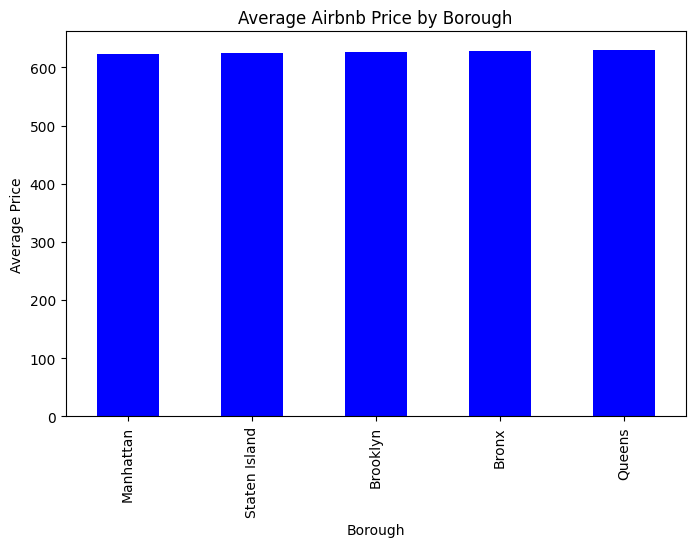

In [32]:
# group data by borough, find the average price for listings in each borough. Sort values in ascending order.
avg_price_by_borough = df.groupby("neighbourhood group")["price"].mean().sort_values()
print(avg_price_by_borough)
#create the plot
plt.figure(figsize=(8,5))
# bar plot in blue
avg_price_by_borough.plot(kind="bar", color="blue")
#labels
plt.title("Average Airbnb Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Price")
plt.show()


# Relation between Roomtype and price?

For this question we will be comparing the average prices of different roomtypes, and plotting it on a bar graph.
- we are able to determine that a hotel room costs the most in new york city compared to shared rooms, private rooms and entire homes.

room type
Entire home/apt    625.051176
Private room       625.138193
Shared room        634.008130
Hotel room         670.517544
Name: price, dtype: float64


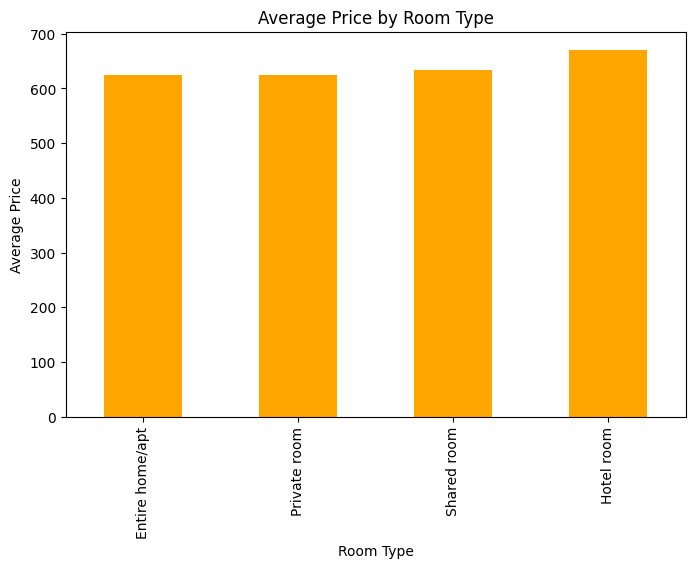

In [33]:
# group the data by room type and get the average of all the prices the roomtype recieved. Sort in ascending  order
# print for easy viewing
avg_price_by_room = df.groupby("room type")["price"].mean().sort_values()
print(avg_price_by_room)

# creating plot
plt.figure(figsize=(8,5))
#making it a bar plot that is orange
avg_price_by_room.plot(kind = "bar", color = "orange")
# setting labels for the plot to make it readable.
plt.title("Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price")
plt.show()


# Which room type recieves most reviews?

For this we will be grouping the data by room type, and seeing how many reviews each recieved overall.

- We can see that Entire homes recieved the most reviews. there is high variance in this data.

room type
Entire home/apt    1454296.0
Private room       1279908.0
Shared room          45064.0
Hotel room            8996.0
Name: number of reviews, dtype: float64


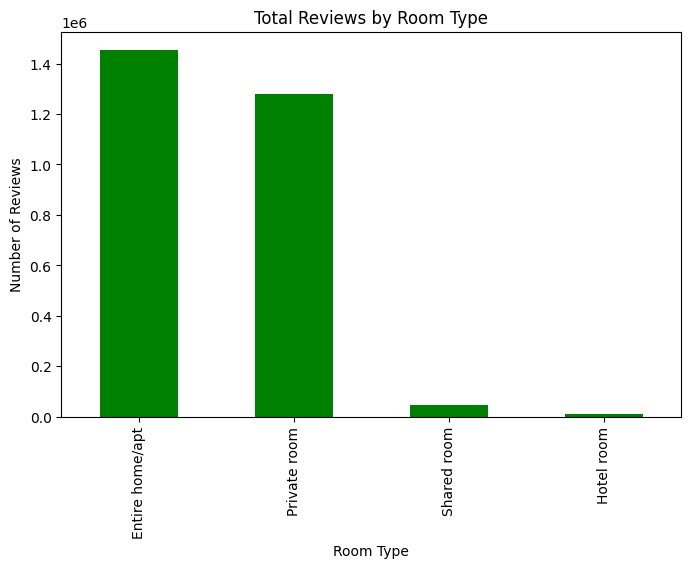

In [34]:
# group the data by room type and get the sum of all the reviews the roomtype recieved. Sort in descending order
# print for easy viewing
reviews_by_room = df.groupby("room type")["number of reviews"].sum().sort_values(ascending=False)
print(reviews_by_room)

# creating plot
plt.figure(figsize=(8,5))
#making it a bar plot that is green
reviews_by_room.plot(kind="bar", color="green")
# setting labels for the plot to make it readable.
plt.title("Total Reviews by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Reviews")
plt.show()


# Which neighborhood has the most airbnb ratings?

For this we will be grouping the data by neighborhoods, and comparing this to the ratings recieved by airbnb listings in each neighborhood.

- We learn that Bedford Stuyvesant has the most reviews on airbnb properties. This may also be the location that most airbnbs are located, or more people tend to go here.

neighbourhood
Bedford-Stuyvesant    270598.0
Williamsburg          188799.0
Harlem                178340.0
Bushwick              122387.0
Hell's Kitchen        111303.0
East Village           96175.0
Crown Heights          89373.0
East Harlem            82665.0
Upper West Side        76758.0
Upper East Side        69868.0
Name: number of reviews, dtype: float64


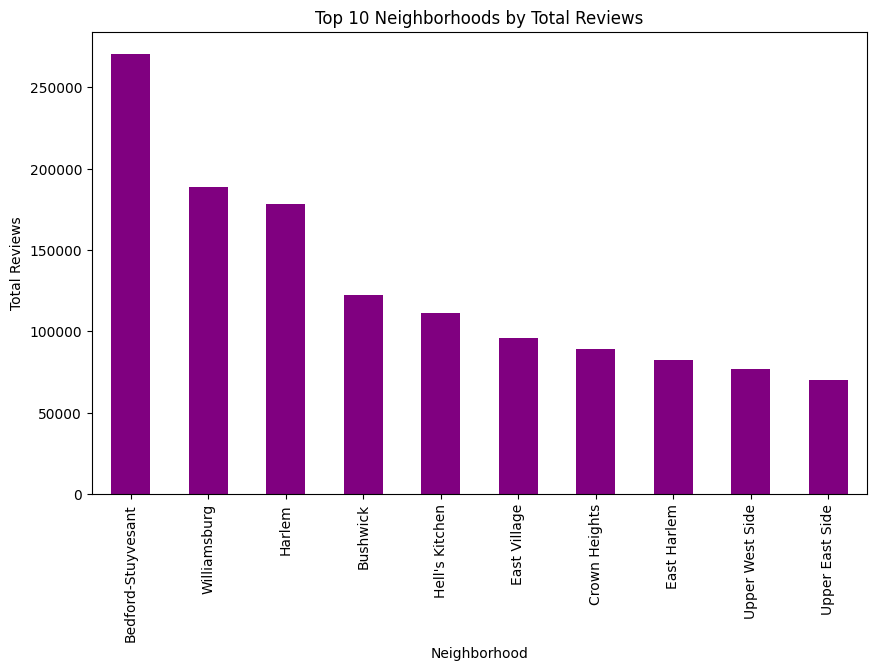

In [35]:
# group the data by neighborhood. Sum up all the reviews for each neighborhood. Look at the top 10 neighborhoods with most ratings.
ratings_by_neighborhood = df.groupby("neighbourhood")["number of reviews"].sum().sort_values(ascending=False)
print(ratings_by_neighborhood.head(10))

# create a large bar plot in purple
plt.figure(figsize=(10,6))
ratings_by_neighborhood.head(10).plot(kind="bar", color="purple")
# create labels to make it more creadable.
plt.title("Top 10 Neighborhoods by Total Reviews")
plt.xlabel("Neighborhood")
plt.ylabel("Total Reviews")
plt.show()


# Which neighborhood has the most airbnb listings?
We will be grouping the data by the neighborhood, then we will count the listings.
- we can confirm a previous assumption that Bedford-Stuyvesant has the most airbnb listings. However, we also learn that Williamsburg has an almost equivalent number listings, but a way lower number of reviews.

neighbourhood
Bedford-Stuyvesant    7888
Williamsburg          7720
Harlem                5427
Bushwick              4947
Hell's Kitchen        3950
Upper West Side       3836
Upper East Side       3646
East Village          3455
Midtown               3368
Crown Heights         3239
Name: count, dtype: int64


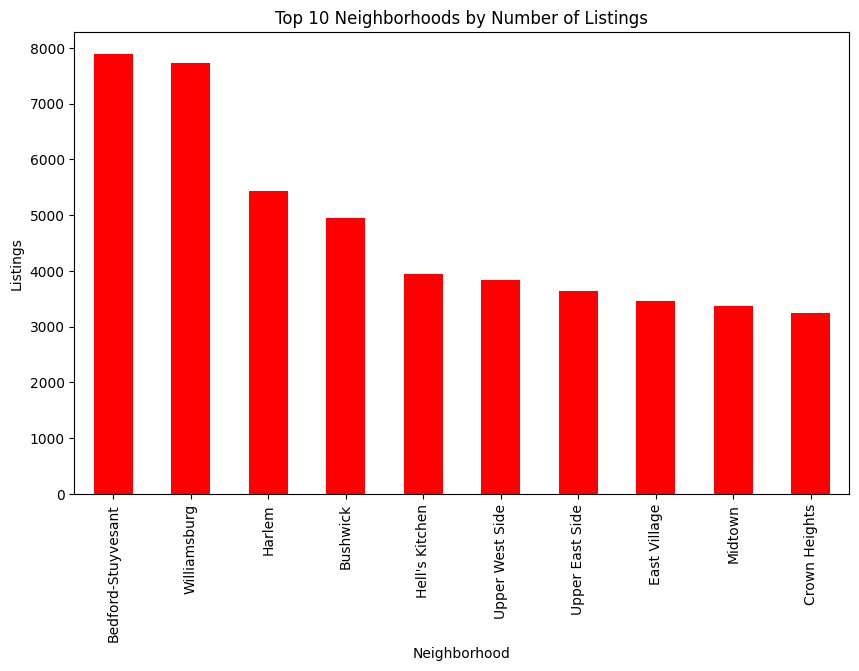

In [36]:
# group by neighborhood and count the number of listings there were overall print the top 10
listings_by_neighborhood = df["neighbourhood"].value_counts()
print(listings_by_neighborhood.head(10))
# create the large plot to fit 10 neighborhoods
plt.figure(figsize=(10,6))
# using red color, and creating bar plot
listings_by_neighborhood.head(10).plot(kind="bar", color="red")
# label it for readability
plt.title("Top 10 Neighborhoods by Number of Listings")
plt.xlabel("Neighborhood")
plt.ylabel("Listings")
plt.show()


# Which neighborhood group has most listings?

We groupt the neighborhood groups/boroughs. We then count the listings in each borough.

- We can see that manhattan has the most listings followed by brooklyn.

neighbourhood group
Manhattan        43484
Brooklyn         41587
Queens           13186
Bronx             2696
Staten Island      948
Name: count, dtype: int64


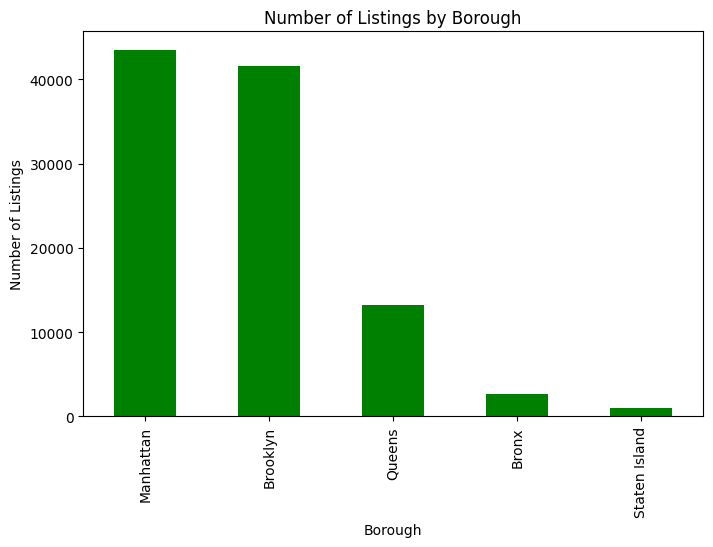

In [39]:
print(df["neighbourhood group"].value_counts())
# create the large plot to fit neighborhoods
plt.figure(figsize=(8,5))
# using green color, and creating bar plot
df["neighbourhood group"].value_counts().plot(kind="bar", color="green")
# label it for readability
plt.title("Number of Listings by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Listings")
plt.show()

# Is there a correlation between the number of reviews and the price?
Our goal is to see if there is a correlation between these 2 factors. We want to know if people visiting NYC and reviewing property prefer cheaper or more expensive options

- there is no correlation between number of reviews and price of the property.

0.0048846917961122465


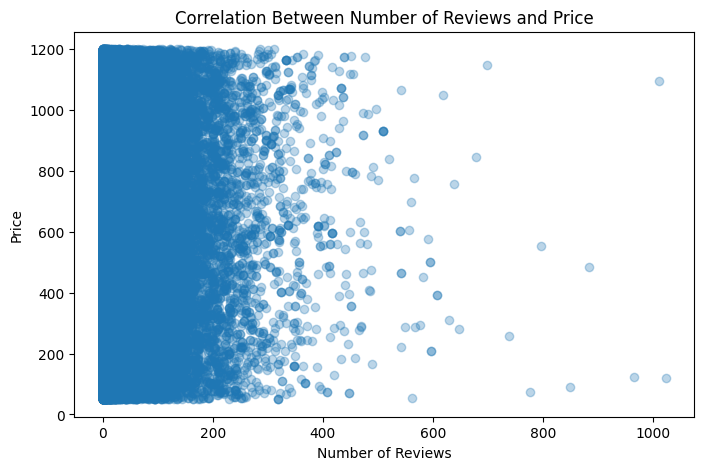

In [ ]:
# calculating the R value for the correlation between the number of reviews and the price of the property.
correlation = df["number of reviews"].corr(df["price"])
print(correlation)
# Creating the scatter plot
plt.figure(figsize=(8,5))
# Using lower transparency to fix crowding problems.
plt.scatter(df["number of reviews"], df["price"], alpha=0.3)
# Label the plot for better readability.
plt.title("Correlation Between Number of Reviews and Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

